In [ ]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import matplotlib as mpl
# import matplotib.font_manager as fm

# 한글 폰트 설정
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지



In [11]:
# 수질 기준 정의
water_quality_standards = {
    "일반세균": ("≤", 100),
    "총대장균군": ("불검출", None),
    "납": ("≤", 0.01),
    "불소": ("≤", 1.5),
    "비소": ("≤", 0.01),
    "셀레늄": ("≤", 0.01),
    "수은": ("≤", 0.001),
    "시안": ("≤", 0.01),
    "크롬": ("≤", 0.05),
    "암모니아성질소": ("≤", 0.5),
    "질산성질소": ("≤", 10),
    "카드뮴": ("≤", 0.005),
    "페놀": ("≤", 0.005),
    "총트리할로메탄": ("≤", 0.1),
    "다이아지논": ("≤", 0.02),
    "파라티온": ("≤", 0.06),
    "1,2-디브로모-3-클로로프로판": ("≤", 0.003),
    "페니트로티온": ("≤", 0.04),
    "카바릴": ("≤", 0.07),
    "1,1,1-트리클로로에탄": ("≤", 0.1),
    "테트라클로로에틸렌": ("≤", 0.01),
    "트리클로로에틸렌": ("≤", 0.03),
    "디클로로메탄": ("≤", 0.02),
    "벤젠": ("≤", 0.01),
    "톨루엔": ("≤", 0.7),
    "에틸벤젠": ("≤", 0.3),
    "크실렌": ("≤", 0.5),
    "1,1-디클로로에틸렌": ("≤", 0.03),
    "사염화탄소": ("≤", 0.002),
    "경도": ("≤", 300),
    "과망간산칼륨소비량": ("≤", 10),
    "동": ("≤", 1),
    "색도": ("≤", 5),
    "세제": ("≤", 0.5),
    "수소이온농도": ("범위", (5.8, 8.5)),
    "아연": ("≤", 3),
    "염소이온": ("≤", 250),
    "증발잔류물": ("≤", 500),
    "철": ("≤", 0.3),
    "망간": ("≤", 0.05),
    "탁도": ("≤", 0.5),
    "황산이온": ("≤", 200),
    "알루미늄": ("≤", 0.2),
    "잔류염소": ("≤", 4.0),
    "붕소": ("≤", 1.0),
    "클로로포름": ("≤", 0.08),
    "대장균/분원성대장균군": ("불검출", None),
    "클로랄하이드레이트": ("≤", 0.03),
    "디브로모아세토니트릴": ("≤", 0.1),
    "디클로로아세토니트릴": ("≤", 0.09),
    "트리클로로아세토니트릴": ("≤", 0.004),
    "할로아세틱에시드": ("≤", 0.1),
    "브로모디클로로메탄": ("≤", 0.03),
    "디브로모클로로메탄": ("≤", 0.1),
    "1,4-다이옥산": ("≤", 0.05),
    "포름알데히드": ("≤", 0.5),
    "브롬산염": ("≤", 0.01),
    "우라늄": ("≤", 30)
}


In [9]:
import os
print(os.getcwd())


c:\Users\lyjin\Desktop\vscode\Data_Anlysis\Seoul_Water


In [14]:
import pandas as pd

df = pd.read_excel("정수장 월별 검사자료관리(2024년).xlsx")
df_clean = df.dropna(subset=['검사년도'])
df.head(10)


,순번,검사년도,검사월,광역시도,시설물번호,정수장명,정수장주소,수원,채수년월일,성적서발행일,...,디브로모아세토니트릴,디클로로아세토니트릴,트리클로로아세토니트릴,할로아세틱에시드,브로모디클로로메탄,디브로모클로로메탄,"1,4-다이옥산",포름알데히드,브롬산염,우라늄
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.1 mg/L,0.09 mg/L,0.004 mg/L,0.1 mg/L,0.03 mg/L,0.1 mg/L,0.05 mg/L,0.5 mg/L,0.01 mg/L,30 ㎍/L
1,1.0,2024.0,1.0,서울특별시,PR00000011,강북,경기도 남양주시 고산로 171,하천수,20240109.0,20240205.0,...,0,0,0,0.007,0.003,0,0,0,0.0007,NaN
2,2.0,2024.0,1.0,서울특별시,PR00000017,광암,경기도 하남시 서하남로 293,하천수,20240109.0,20240205.0,...,0,0.0006,0,0.008,0.004,0.001,0,0,0,NaN
3,3.0,2024.0,1.0,서울특별시,PR00000023,구의,서울특별시 광진구 광나루로 571,하천수,20240109.0,20240205.0,...,0,0,0,0.008,0.004,0,0,0,0,NaN
4,4.0,2024.0,1.0,서울특별시,PR00000026,뚝도,서울특별시 성동구 왕십리로 27,하천수,20240109.0,20240205.0,...,0,0,0,0.007,0.004,0,0,0,0,NaN
5,5.0,2024.0,1.0,서울특별시,PR00000046,암사,서울특별시 강동구 아리수로 131,하천수,20240109.0,20240205.0,...,0,0,0,0.007,0.004,0,0,0,0,NaN
6,6.0,2024.0,1.0,서울특별시,PR00000052,영등포,서울특별시 영등포구 노들로 11,하천수,20240109.0,20240205.0,...,0,0.0006,0,0.012,0.005,0.001,0,0,0,NaN
7,7.0,2024.0,2.0,서울특별시,PR00000011,강북,경기도 남양주시 고산로 171,하천수,20240206.0,20240305.0,...,0,0,0,0.006,0.003,0,0,0,0,NaN
8,8.0,2024.0,2.0,서울특별시,PR00000017,광암,경기도 하남시 서하남로 293,하천수,20240206.0,20240305.0,...,0,0,0,0.007,0.004,0.002,0,0,0,NaN
9,9.0,2024.0,2.0,서울특별시,PR00000023,구의,서울특별시 광진구 광나루로 571,하천수,20240206.0,20240305.0,...,0,0,0,0.007,0.004,0.001,0,0,0,NaN


In [18]:

def check_violation(row):
    violation_count = 0
    for item, (cond, val) in water_quality_standards.items():
        if item not in row or pd.isna(row[item]):
            continue
        try:
            r = float(row[item])
            if cond == "≤" and r > val:
                violation_count += 1
            elif cond == "범위" and not (val[0] <= r <= val[1]):
                violation_count += 1
        except:
            if cond == "불검출" and str(row[item]).strip() != "0":
                violation_count += 1
    return violation_count

df_clean["위험지수"] = df_clean.apply(check_violation, axis=1)
df_clean["라벨"] = df_clean["위험지수"].apply(lambda x: 1 if x > 0 else 0)
df_clean[["정수장명", "광역시도", "검사월", "위험지수", "라벨"]].head()

C:\Users\lyjin\AppData\Local\Temp\ipykernel_21700\2071370069.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["위험지수"] = df_clean.apply(check_violation, axis=1)
C:\Users\lyjin\AppData\Local\Temp\ipykernel_21700\2071370069.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["라벨"] = df_clean["위험지수"].apply(lambda x: 1 if x > 0 else 0)


,정수장명,광역시도,검사월,위험지수,라벨
1,강북,서울특별시,1.0,2,1
2,광암,서울특별시,1.0,2,1
3,구의,서울특별시,1.0,2,1
4,뚝도,서울특별시,1.0,2,1
5,암사,서울특별시,1.0,2,1


In [19]:
print("개수 ", len(df_clean))

개수  42


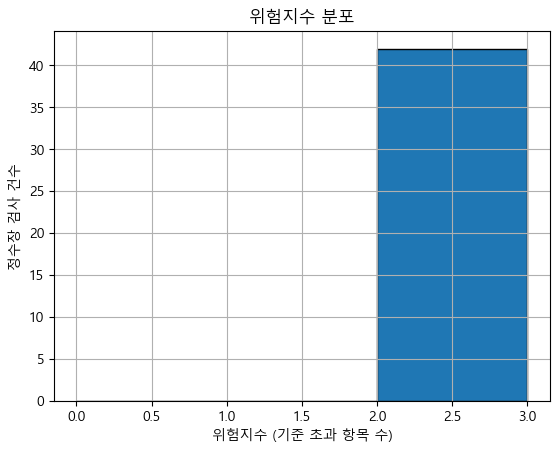

In [16]:
import matplotlib.pyplot as plt

plt.hist(df_clean["위험지수"], bins=range(0, df_clean["위험지수"].max()+2), edgecolor='black')
plt.title("위험지수 분포")
plt.xlabel("위험지수 (기준 초과 항목 수)")
plt.ylabel("정수장 검사 건수")
plt.grid(True)
plt.show()
